In [1]:
import control as ct
import matplotlib.pyplot as plt
import math
import numpy as np
import cvxpy as cp
import networkx as ntx # TODO: use this
from scipy.integrate import solve_ivp
import os
import copy
import random

from control_utils.politopic_representation import *
from control_utils.uio import *
from control_utils import levants
from scipy.sparse import find

from IPython.display import clear_output
%matplotlib widget

rng_seed = 5

np.random.seed(rng_seed)
random.seed(rng_seed)

In [2]:
# Constants
k = 10
b = 1.3
m = 0.25

# Number of subsystems
N = 6

# Convergance rate
eta = 7

# Simulation time
time = 10

# tolerance
eps = 1e-12

In [3]:
# Initial States
x0_systems = np.array([
     2,  1,
     3,  2,
    -1,  0,
     3, -2,
     0, -5
    -2,  2,
])/10
x0_observer = np.zeros(x0_systems.shape)
# x0_observer = np.array([
#      3, -2,
#      2,  1,
#      3,  2,
#     4,  2,
#     -1,  0,
#      0, -9
# ])+1
x0_levants = np.zeros(5*N)

x0 = np.concat([x0_systems, x0_observer, x0_levants], axis=0)

In [4]:
# System matrices
A_sys = np.array([
    [ 0, 1 ],
    [ -k/m, -b/m]
])

A = np.array([
    [ 0, 1 ],
    [ 0, 0]
])

C = np.array([
    [ 1, 0 ]
])

A, C

(array([[0, 1],
        [0, 0]]),
 array([[1, 0]]))

In [5]:
# Observability
np.linalg.matrix_rank(ct.obsv(A, C)) == A.shape[0]

np.True_

In [6]:
# Validite domain of the model (D) -> TODO: update values - but as it is linear it should be R2
# hyperplanes
a_i = np.array([
    [1, -1, 0, 0],
    [0, 0, 1, -1]
])
b_i = np.array([10, 10, 100, 100]).reshape(4, 1)+1

# Subset of D -> used to guarantee x_hat stays in D
bR_i = np.array([10, 10, 100, 100]).reshape(4, 1)

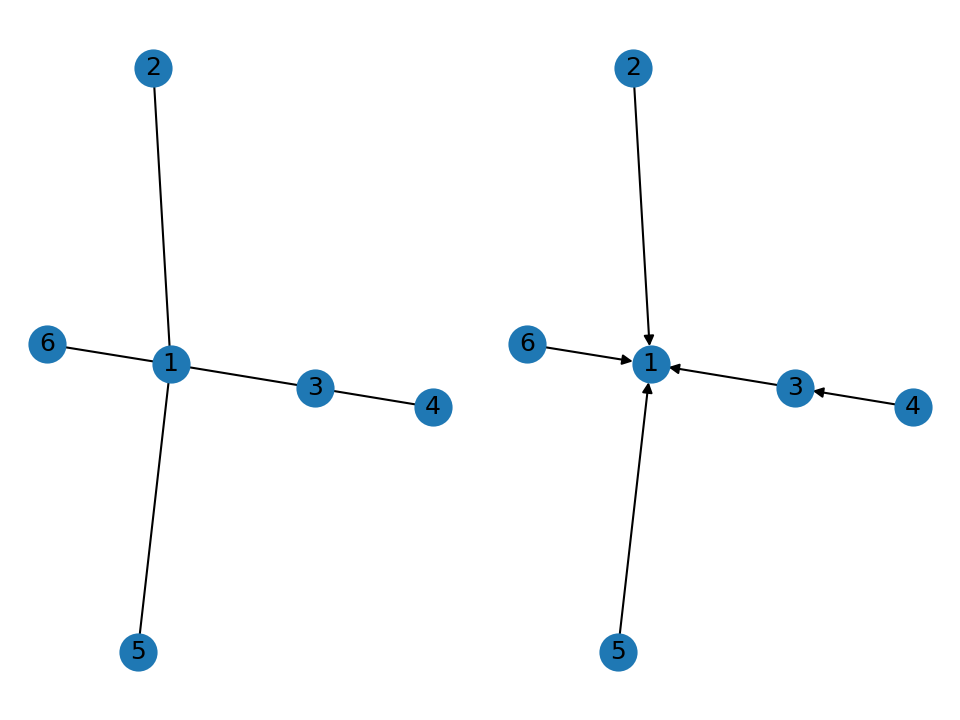

In [7]:
# Connections Graph construction
m = 1    # random min initial conections
p = 0.04 # probability to add m new edges
q = 0.02 # probability to alter m existing edges

# G = ntx.barabasi_albert_graph(10, 1, seed=10) # no cycles
# G = ntx.erdos_renyi_graph(20, .2) # random edges
G = ntx.extended_barabasi_albert_graph(N, m, p, q, seed=rng_seed) # both cycles and direct connections

mapping = {i: i + 1 for i in G.nodes()}
G = ntx.relabel_nodes(G, mapping)

dG = ntx.DiGraph(G)
dG.remove_edges_from([(1, 2), (1, 3), (1, 5), (3, 4), (2, 6), (1, 6)])

def plot_G():
    plt.figure(dpi=150, constrained_layout=True)
    plt.subplot(1, 2, 1)
    nodes_pos = ntx.spring_layout(G, pos={'0': (0, 0)}, iterations=500, seed=rng_seed)
    ntx.draw(G, pos=nodes_pos, with_labels=True)
    plt.subplot(1, 2, 2)
    ntx.draw(dG, pos=nodes_pos, with_labels=True)
    plt.show()

plot_G()

In [8]:
# use adj matrix of G to create interconections
# use adj matrix of dG to rebuild g_ij
# ntx.to_numpy_array(dG) # adjacency - outbound look at rows - inbound deals with col

In [9]:
# LMIs
nx = A.shape[0]
ny = C.shape[0]

P_trace = 0
P_cell = []
L_till_cell = []

for i in range(N):
    P_i = cp.Variable((nx, nx), symmetric=True)
    L_till_i = cp.Variable((nx, ny))

    P_cell.append(P_i)    
    L_till_cell.append(L_till_i)

constrains = []

for i in range(N):

    P_trace += cp.trace(P_cell[i])
    constrains += [ P_cell[i] >> eps ] # the same as P > 0

    M = P_cell[i]@A - L_till_cell[i]@C + eta*P_cell[i]
    constrains += [ M + M.T << -eps ] # linear case
        
    for j in range(a_i.T.shape[0]): # check the need for this one as the model is linear
        aj = np.expand_dims(a_i.T[j], axis=1)
        phi = phi_z(a_i.T, aj, bR_i) # still necessary?
        sj = 1/(b_i[j] - phi) * aj

        M = cp.bmat([
            [np.eye(1), sj.T],
            [sj       , P_cell[i]],
        ])
        constrains += [ M >> 0 ]

P_diag = cp.bmat([
    [P_cell[0], np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), P_cell[1], np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), P_cell[2], np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), P_cell[3], np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), P_cell[4], np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), P_cell[5]],
    
])

prob = cp.Problem(cp.Minimize(cp.trace(P_diag)), constraints=constrains)
result = prob.solve(solver=cp.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Nov 13 09:36:32 PM: Your problem has 36 variables, 264 constraints, and 0 parameters.
(CVXPY) Nov 13 09:36:32 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Nov 13 09:36:32 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Nov 13 09:36:32 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Nov 13 09:36:32 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Nov 13 09:36:32 PM: Compiling problem (target solver=MOSEK).
(

In [10]:
for i in range(N):
    print(f"i: {i+1}, P: {P_cell[i].value}, \nL_till: {L_till_cell[i].value}")
    print()

i: 1, P: [[196.00504821 -13.92930377]
 [-13.92930377   1.98990054]], 
L_till: [[1.40678071e+03]
 [9.94795495e-01]]

i: 2, P: [[196.00504821 -13.92930377]
 [-13.92930377   1.98990054]], 
L_till: [[1.40678071e+03]
 [9.94795495e-01]]

i: 3, P: [[196.00504821 -13.92930377]
 [-13.92930377   1.98990054]], 
L_till: [[1.40678071e+03]
 [9.94795495e-01]]

i: 4, P: [[196.00504821 -13.92930377]
 [-13.92930377   1.98990054]], 
L_till: [[1.40678071e+03]
 [9.94795495e-01]]

i: 5, P: [[196.00504821 -13.92930377]
 [-13.92930377   1.98990054]], 
L_till: [[1.40678071e+03]
 [9.94795495e-01]]

i: 6, P: [[196.00504821 -13.92930377]
 [-13.92930377   1.98990054]], 
L_till: [[1.40678071e+03]
 [9.94795495e-01]]



In [11]:
is_positive_defined = []
for i in range(N):
    i_is_positive_defined = True if all(np.linalg.eig(P_cell[i].value).eigenvalues > 0) else False
print(f'e.g.: P[1] = \n{P_cell[0].value}')
print(f"The solution is \'{prob.status}\', with Trace(P) = {result:.2f} and P is {"Positive Defined" if all(is_positive_defined) else "NOT Positive Defined"}")

e.g.: P[1] = 
[[196.00504821 -13.92930377]
 [-13.92930377   1.98990054]]
The solution is 'optimal', with Trace(P) = 1187.97 and P is Positive Defined


In [12]:
L_cell = []

for i in range(N):
    P_i_inv = np.linalg.inv(P_cell[i].value)
    L_cell.append(P_i_inv@L_till_cell[i].value)
    print(L_cell[i])

[[ 14.35274518]
 [100.9691385 ]]
[[ 14.35274518]
 [100.9691385 ]]
[[ 14.35274518]
 [100.9691385 ]]
[[ 14.35274518]
 [100.9691385 ]]
[[ 14.35274518]
 [100.9691385 ]]
[[ 14.35274518]
 [100.9691385 ]]


In [13]:
# Simulation
def f_x(x_i: np.ndarray) -> np.ndarray[float]:
    """System Dynamics

    Parameters
    ----------
    x_i : np.ndarray
        i-th system states
    
    Returns
    f(x_i) : np.ndarray
    """
    # print(f"x_i: {x_i}, shape: {x_i.shape}")
    # print(f"A@x_i: {A@x_i}, shape: {(A@x_i).shape}")
    return np.expand_dims(A_sys@x_i, axis=1)

def h_x(x_i: np.ndarray) -> np.ndarray[float]:
    """System output

    Parameters
    ----------
    x_i : np.ndarray
        i-th system states
    
    Returns
    h(x_i) : np.ndarray
    """
    return np.expand_dims(C@x_i, axis=1)

def gd_x(i: int, n: int, N: int, x: np.ndarray, G: ntx.Graph) -> list[np.ndarray[float], np.ndarray[float]]: # check if this typing is correct
    """Calculates UIs

    Parameters
    ----------
    i : int
        Current system - 1 based index
    n : int
        Number of states
    N : int
        Number of subsystems
    x : np.ndarray
        All states
    G : ntx.Graph
        Graph of interconnections
    
    Returns
    ----------
    G*d(x), d(x) : np.ndarray[float], np.ndarray
    """

    # TODO: handle this differently
    # removing levants differentiations and observer
    # n = (x.shape[0] - 4) // (2*G.number_of_nodes())
    gd = np.zeros(n)
    gd_decoupled = []
    
    i_id = (i-1) * n
    x_i = x[i_id:i_id+n]
    
    # print(f"x: {x}, x_i[{i-1}]: {x_i}, i_id: {i_id}")

    for edge in G.edges(i):
        j = edge[1] - 1 # mapping from 1~N to 0~N-1
        j_id = j * n
        x_j = x[j_id:j_id+n]

        # affects only the second state
        # print(f"x_j[{j_id/2}]: {x_j}, x_i[{i-1}]: {x_i}")
        d = -math.tanh(x_j[1] - x_i[1])
        gd[1] += d

        # print(f"edge: {edge}, d: {d}")

        gd_decoupled.append(d)

    gd = gd.reshape((n, 1))
    gd_decoupled = np.array(gd_decoupled).reshape(len(gd_decoupled), 1)

    return gd, gd_decoupled

def G_i() -> np.ndarray:
    return np.array([
        [0],
        [-1] # TODO: fix with degree
    ]).reshape((2, 1))

def Gamma_inv() -> np.ndarray:
    """Calculates Gamma_inv(x)

    Returns
    ----------
    Gamma_inv : np.ndarray
    """
    Gamma = G_i()[1]

    return np.array(1/Gamma)

def Q_x() -> np.ndarray:
    """Calculates Q(x)
    
    Returns
    ----------
    Q(x) : np.ndarray
    """
    g_i = G_i()
    gamma_inv = Gamma_inv()
    Q  = g_i@gamma_inv # TODO: check why i need to force this -1

    return np.expand_dims(Q, axis=1)

def Psi_x(x_i: np.ndarray):
    Psi = f_x(x_i)[1]
    Psi = np.array(Psi).reshape((len(Psi), 1))

    return Psi

def dot_Y_levants(y: np.ndarray[float], Y_levants: np.ndarray[float]) -> np.ndarray[float]:
    """Returns dot_Y_levants
    """

    # z1 = y1 = x2
    # z2 = dot_y1 = dot_x2
    # Only necessary up to z2 but higher order helps improve quality 
    lambda_y1 = .5*np.array([31, 29, 26, 21, 16]) # .38S

    n_y1 = lambda_y1.shape[0]
    id_y1 = 0

    z_y1 = Y_levants[id_y1:n_y1]
    y1 = y[0]

    dot_y1 = levants.differentiator(y1, z_y1, lambda_y1)

    return np.concat([dot_y1], axis=0)

import time as time_module
def model(t: float, x: np.ndarray[float], nx: int, G: ntx.Graph, dist_hist: list[list]):
    """Simulates system model
    
    Parameters:
    ----------
    t : float
        Current simulation time in seconds
    x : np.ndarray[float]
        Current system states / observer states / levants integrated
    G : ntx.Graph
        Graph of interconections
    dist_hist : list[list]
        empty list to store UI history
    
    Returns
    ----------
    dot_x : np.ndarray
    """

    print(f"t={t}s")

    # system states / observer states / levants integrated
    xdot = np.zeros(shape=x.shape)
    xdot = np.expand_dims(xdot, axis=1)

    # TODO: handle this differently
    # removing levants differentiations and observer
    N = G.number_of_nodes()
    # nx = (x.shape[0] - 4) // (2*G.number_of_nodes())

    x_i_cell = []
    x_hat_i_cell = []
    Y_levants_i_cell = []

    for i in range(N):
        id = i * nx
        id_hat = id + N*nx
        id_levants = id_hat + N*nx

        x_i_cell.append(x[id:id+nx])
        x_hat_i_cell.append(x[id_hat:id_hat+nx])
        Y_levants_i_cell.append(x[id_levants:id_levants+5])

    dist_hist[0].append(t)
    for i in range(N):
        id = i * nx
        id_hat = id + N*nx
        id_Y_levants = id_hat + N*nx

        x_i = x_i_cell[i]
        x_hat_i = x_hat_i_cell[i]
        Y_levants_i = Y_levants_i_cell[i]

        # print(f"here: {i}")
        i_mapped = i + 1
        d_i, d_i_decoupled = gd_x(i_mapped, nx, N, x, G)

        rd = np.zeros(shape=(2, 1))
        if t >= 2 and t < 6:
            rd[1] = .1
        elif t >= 6 and t < 10:
            rd[1] = -.1
        elif t >= 10:
            rd[1] = .2
            rd = np.random.random(2).reshape(2, 1)*.0001

        # rd[0] = rd[1]
        
        xdot[id:id+nx] = f_x(x_i) + d_i + rd
        y_i = h_x(x_i)
        y_i_hat = h_x(x_hat_i)

        Q = Q_x()
        # print(f"Q: {Q}")
        Psi_hat = Psi_x(x_hat_i)
        Y = np.array([
            Y_levants_i[2] # levants differentiattor
            # xdot[id+1, 0] # exact value
        ])

        L = L_cell[i]

        d_hat_decoupled = Gamma_inv()@(Y - Psi_hat)

        delta = np.expand_dims(y_i - y_i_hat, axis=1)
        xdot[id_hat:id_hat+nx] = f_x(x_hat_i) + Q@(Y - Psi_hat) + L@delta # delta

        dot_Y = dot_Y_levants(h_x(x_hat_i.reshape(2, 1)), Y_levants_i)
        xdot[id_Y_levants:id_Y_levants+5] = dot_Y

        if len(dist_hist) < i + 2:
            dist_hist.append([[], [], [], []])
        
        dist_hist[i+1][0].append(d_i_decoupled)
        dist_hist[i+1][1].append(d_hat_decoupled)
        dist_hist[i+1][2].append(xdot[id:id+nx])
        dist_hist[i+1][3].append(rd)

    # raise
    
    return xdot.flatten()

In [14]:
sim_time = (0, time)
dist_hist = [[]]

result = solve_ivp(model, sim_time, x0, args=(A.shape[0], G, dist_hist), method="BDF", dense_output=True)  # LSODA
clear_output(wait=False)

t = result.t
x = result.y

In [15]:
# Convert dist_hist to np array
dist_hist[0] = np.array(dist_hist[0])
for i in range(1, len(dist_hist)):
    for j in range(len(dist_hist[i])):
        dist_hist[i][j] = np.array(dist_hist[i][j])

In [16]:
dist_hist_filtered = []

# filter to only data matching with t values
# idx = np.searchsorted(dist_hist[0], t, side='left')
idx = np.searchsorted(dist_hist[0], t, side='right') - 1

dist_hist[0] = dist_hist[0][idx]
for i in range(1, len(dist_hist)):
    for j in range(len(dist_hist[i])):
        dist_hist[i][j] = dist_hist[i][j][idx]

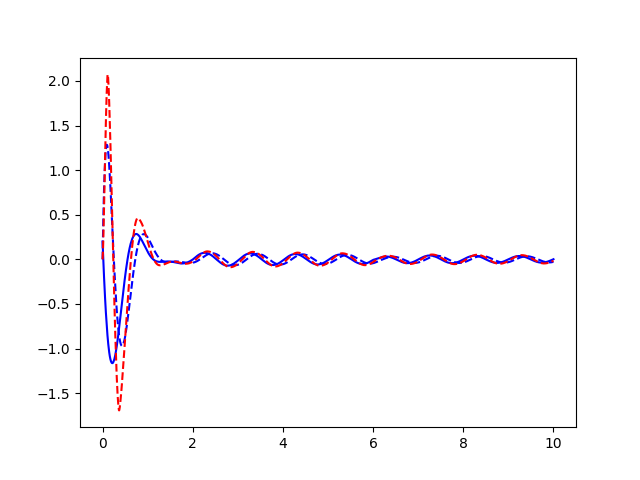

In [17]:
i = 1
x_i = 1
id = i * nx + x_i
id_hat = id + N*nx
id_Y_levants = id + 2*N*nx

plt.figure()
plt.plot(t, x[id], 'b')
plt.plot(t, x[id_hat], 'b--')
# plt.plot(t, dist_hist[i+1][2][:, x_i-1], 'k--')
plt.plot(t, x[id_Y_levants], 'r--')
plt.show()

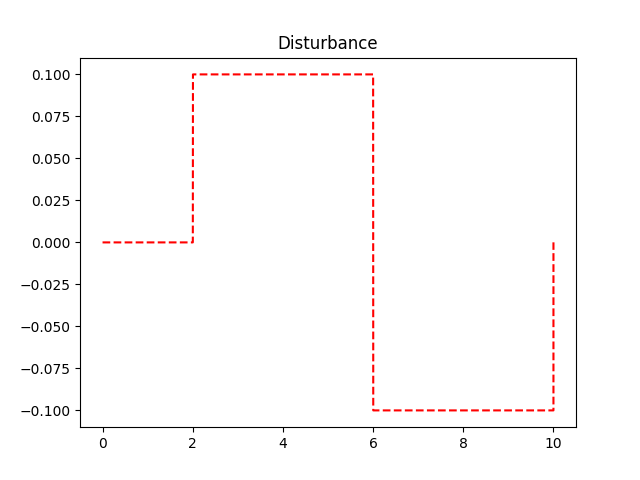

In [18]:
# Disturbance
i = 3
x_i = 1
plt.figure()
plt.title("Disturbance")
plt.plot(t, dist_hist[i][3][:, x_i], 'r--')
plt.show()

In [19]:
dG_adj_matrix = ntx.adjacency_matrix(dG)
G_adj_matrix = ntx.adjacency_matrix(G)

def rebuild_d(t_ind: int, i: int, n: int, x: np.ndarray, d_hist: list, d_rebuilt: list, G: ntx.Graph, dG: ntx.DiGraph) -> list[np.ndarray[float]]:
    """
    Parameters
    ----------
    t_ind : int
        Current time index
    i: int
        Current System - 0 based index
    """
    # print(f"i: {i}")
    
    
    has_anything_to_rebuid = np.sum(dG_adj_matrix[[i], :]) != 0
    if not has_anything_to_rebuid:
        return None

    # d_rebuilt_i = np.copy(d_hist[i+1][1][-1]) # [0: time; i+1: each subsystem][1: d_sum][last_time]
    d_rebuilt_i = d_hist[i+1][1][t_ind, 0] # [0: time; i+1: each subsystem][1: d_sum][last_time]

    has_only_one_connection = np.sum(G_adj_matrix[:, [i]]) == 1

    # print(f"i: {i} rebuilting with only one as: {has_only_one_connection}")

    if not has_only_one_connection:
        for j in range(N):
            if dG_adj_matrix[j, i] == 1:
                # print(f"{i}: d_rebuilt[{j}]: {d_rebuilt[j][-1]}")
                # TODO: handle signal
                # d_rebuilt += d_rebuilt[j+1][2][-1] # each rebuilt signal ha only one value in the list
                d_rebuilt_i += d_rebuilt[j][-1] # each rebuilt signal ha only one value in the list
    
    return d_rebuilt_i

In [20]:
d_rebuilt = []
for i in range(N):
    d_rebuilt.append([])

for i in range(len(dist_hist[0])):
    rebuild_order = [0, 1, 3, 4, 5, 2]
    for j in rebuild_order: # takes to much time - can be run outside after cleanning out t
        d_rebuilt_i = rebuild_d(i, j, nx, x, dist_hist, d_rebuilt, G, dG)
        d_rebuilt[j].append(d_rebuilt_i)

d_rebuilt = np.array(d_rebuilt)

In [21]:
def plot_graph(x, nx):
    plt.figure(dpi=150, constrained_layout=True)
    # plt.suptitle(f'{N}-Interconnected Oscilators', y=1.0)

    cols = 2
    rows = math.ceil(N/cols)

    for i in range(N):
        ind = i * nx
        ind_hat = ind + N*nx

        plt.subplot(rows, cols, i+1)
        plt.title(f"Oscilator {i+1}", fontsize=8)
        plt.scatter(x0[ind], x0[ind+1], s=30, facecolors='none', edgecolors='k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(x[ind, :], x[ind+1, :], 'k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(x[ind_hat, :], x[ind_hat+1, :], 'r--', linewidth=1) #, label=f'$\\mathbf{{\\hat{{x}}}}_{i+1}$')
        # plt.xlabel("$x_1$")
        # plt.ylabel("$x_2$")
        # plt.legend()
        
        plt.grid(which='both')
    
    legend = plt.figlegend([r'$\mathbf{x}_0$', r'$\mathbf{x}$', r'$\mathbf{\hat{x}}$'], loc = 'lower center', ncol = 3,  bbox_to_anchor=(0.5, -0.1))

    dir = os.path.join(os.curdir, f'.figures/')
    if not os.path.isdir(dir):
        os.mkdir(dir)

    plt.savefig(f".figures/dynamics_{N}", dpi=600, bbox_inches='tight', bbox_extra_artists=[legend])
    plt.show()

def plot_graph_dist(dist_hist):
    plt.figure(dpi=150, constrained_layout=True)

    cols = 2
    rows = math.ceil(N/cols)

    for i in range(N):
        ind = i * nx
        ind_hat = ind + N*nx

        plt.subplot(rows, cols, i+1)
        plt.title(f"Oscilator {i+1}", fontsize=8)

        plt.plot(t, np.sum(dist_hist[i+1][0], axis=1), 'k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(t, -dist_hist[i+1][1], 'r--', linewidth=1) #, label=f'$\\mathbf{{\\hat{{x}}}}_{i+1}$')
        
        # plt.xlabel("$x_1$")
        # plt.ylabel("$x_2$")
        # plt.legend()
        
        plt.ylim([-1, 1])
        plt.grid(which='both')
    
    # legend = plt.figlegend([r'$\mathbf{x}_0$', r'$\mathbf{x}$', r'$\mathbf{\hat{x}}$'], loc = 'lower center', ncol = 3,  bbox_to_anchor=(0.5, -0.1))

    # # dir = os.path.join(os.curdir, f'.figures/')
    # # if not os.path.isdir(dir):
    # #     os.mkdir(dir)

    # plt.savefig(f".figures/dynamics_{N}", dpi=600, bbox_inches='tight', bbox_extra_artists=[legend])
    plt.show()

def plot_graph_dist_ind(i, dist_hist, dist_rec, G, dG):
    plt.figure(dpi=150, constrained_layout=True)

    plt.title(f"Oscilator {i+1}", fontsize=8)

    color = ['k', 'b']
    hat_color = ['r', 'k']
    
    plt.plot(t, np.sum(dist_hist[i+1][0], axis=1), 'g', label=f'$\\Sigma$') # sum
    plt.plot(t, -np.sum(dist_hist[i+1][1], axis=1), 'g--', label=f'$\hat{{\\Sigma}}$') # sum

    for j, edge in zip(range(dist_hist[i+1][0][0].shape[0]), G.edges(i+1)):
        plt.plot(t, np.sum(dist_hist[i+1][0][:, j], axis=1), color[j], label=f'$\\mathbf{{d}}_{{{edge[0]}{edge[1]}}}$')
    
    for j, edge in zip(range(dist_rec.shape[0]), dG.edges(i+1)):
        plt.plot(t, -dist_rec[i], hat_color[j], linewidth=1, label=f'$\\hat{{\\mathbf{{d}}}}_{{{edge[0]}{edge[1]}}}$')
    
    plt.xlabel("$t$")
    # plt.ylabel("$x$")
    plt.legend()
    
    plt.grid(which='both')
    
    # legend = plt.figlegend([r'$\mathbf{x}_0$', r'$\mathbf{x}$', r'$\mathbf{\hat{x}}$'], loc = 'lower center', ncol = 3,  bbox_to_anchor=(0.5, -0.1))

    # # dir = os.path.join(os.curdir, f'.figures/')
    # # if not os.path.isdir(dir):
    # #     os.mkdir(dir)

    # plt.savefig(f".figures/dynamics_{N}", dpi=600, bbox_inches='tight', bbox_extra_artists=[legend])
    plt.show()

<>:73: SyntaxWarning: invalid escape sequence '\h'
<>:73: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_31192\3631719233.py:73: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(t, -np.sum(dist_hist[i+1][1], axis=1), 'g--', label=f'$\hat{{\\Sigma}}$') # sum


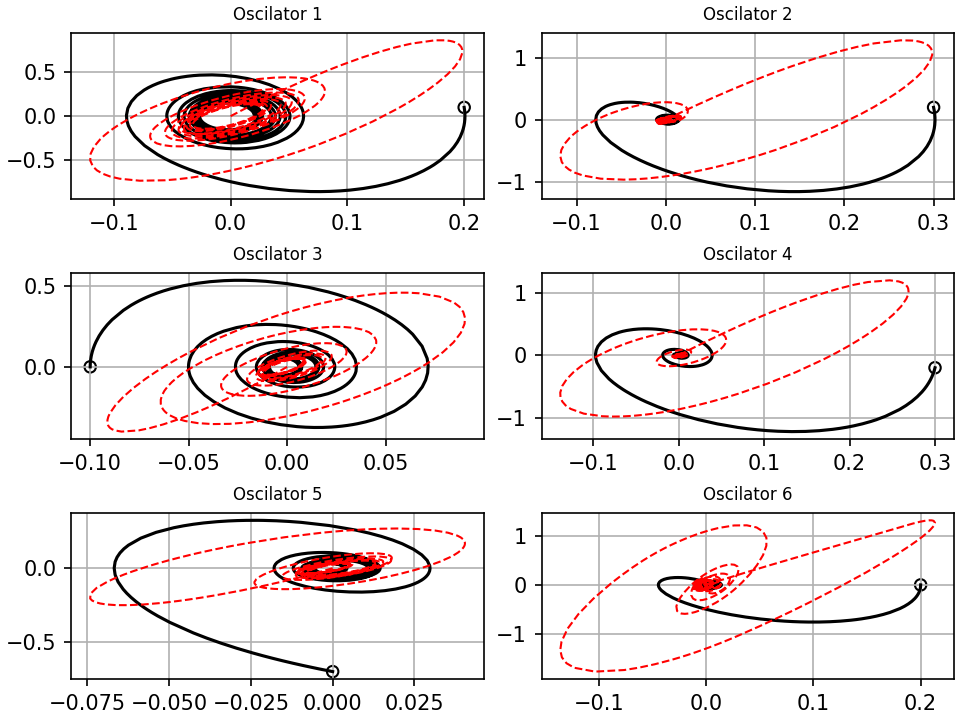

In [22]:
plot_graph(x, 2)

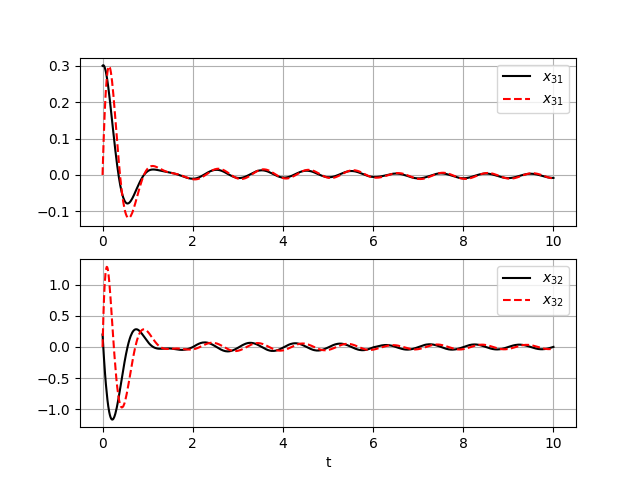

In [23]:
# Dynamics of one oscilator
i = 3
id = i - 1
id_hat = id + N*nx
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(t, x[id, :], 'k', label=f'$x_{{{i}1}}$')
plt.plot(t, x[id_hat, :], 'r--', label=f'$x_{{{i}1}}$')
# plt.ylim([-.02, .02])
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t, x[id+1, :], 'k',  label=f'$x_{{{i}2}}$')
plt.plot(t, x[id_hat+1, :], 'r--',  label=f'$x_{{{i}2}}$')
# plt.ylim([-.08, .08])
plt.xlabel('t')
plt.grid()
plt.legend()
plt.show()

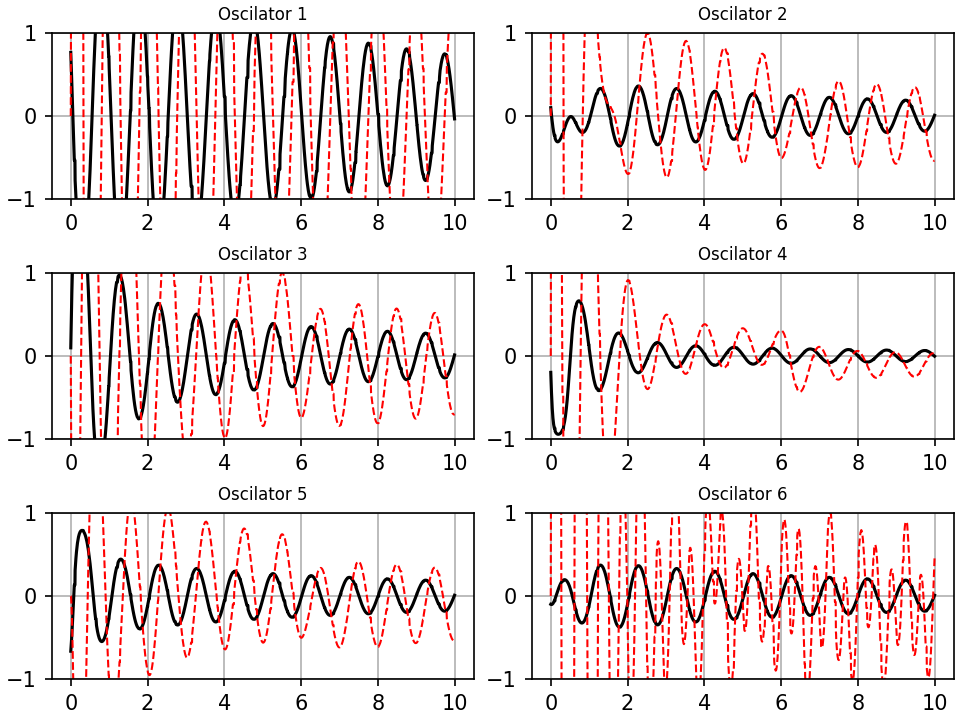

In [24]:
# Plot of dist sums and its estimation
plot_graph_dist(dist_hist)

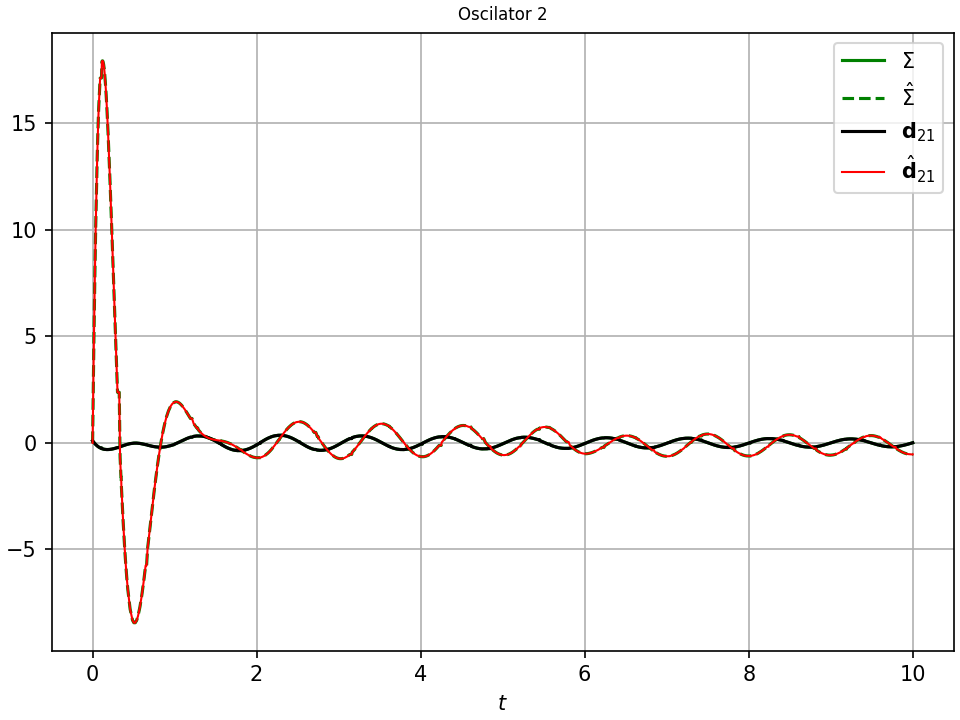

In [ ]:
# Plot of each individual dist and its individual reconstruction
i = 1
plot_graph_dist_ind(i-1, dist_hist, d_rebuilt, G, dG)

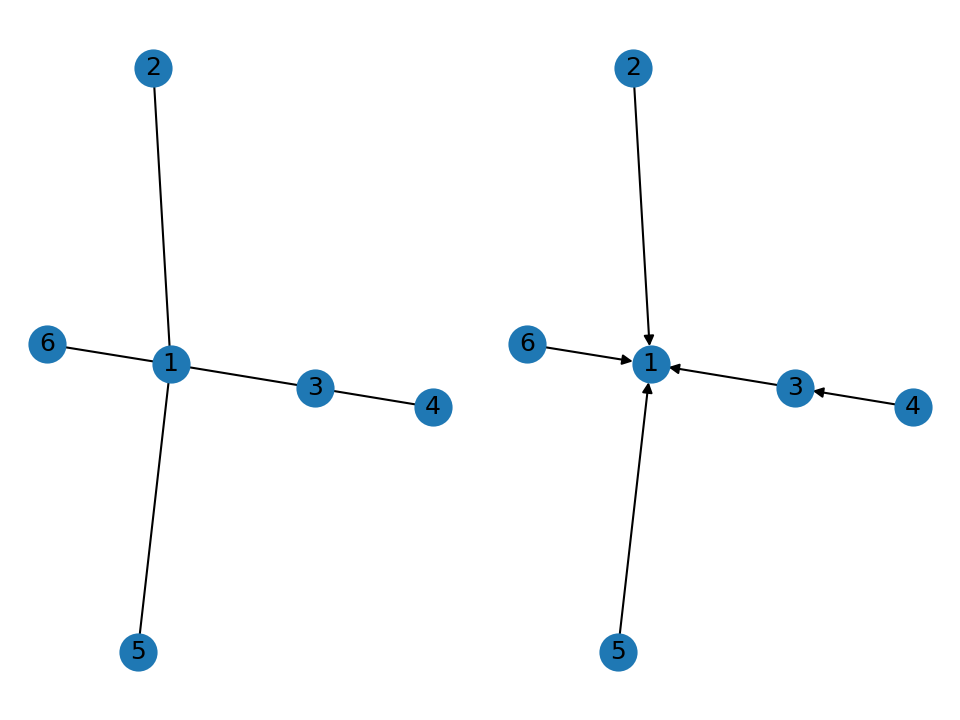

In [26]:
plot_G()